# TraceWinEnv one-step debug

This notebook runs the smallest useful TraceWinEnv check:

1. verify that SSH to `comunian@localhost` is reachable;
2. instantiate `TraceWinEnv`;
3. call `reset()`;
4. call one `step()` with zero action;
5. print the simulator result, errors, score, and files written in `calc_dir`;
6. optionally render the episode and final phase-space distribution.

It is meant for debugging TraceWin itself, not for training or policy evaluation.


In [13]:
from __future__ import annotations

import os
import subprocess
import sys
import traceback
import time
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "beam_optimization").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repository root from {start}")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from beam_optimization.config.paths import DEFAULT_TRACEWIN_INI
from beam_optimization.env.tracewin_env import TraceWinEnv

SEED = 123
TIMEOUT_SECONDS = 25.0
RETRIES = 0

project_file = Path(DEFAULT_TRACEWIN_INI)
calc_dir = project_file.parent / "calc_debug_env"

print(f"repo_root    = {REPO_ROOT}")
print(f"project_file = {project_file}")
print(f"calc_dir     = {calc_dir}")


repo_root    = /mnt/shared_volume/FEDERICO_TESI
project_file = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini
calc_dir     = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env


In [14]:
def list_calc_files(path: Path) -> None:
    if not path.exists():
        print(f"calc_dir does not exist: {path}")
        return
    files = sorted(p for p in path.iterdir() if p.is_file())
    if not files:
        print("calc_dir is empty")
        return
    for p in files:
        print(f"{p.name:<28} {p.stat().st_size:>12,} bytes")


def print_sim_result(label: str, info: dict) -> None:
    result = info.get("sim_result")
    print()
    print(f"[{label}]")
    print(f"score = {info.get('score')}")
    if result is None:
        print("sim_result missing")
        return
    print(f"success     = {result.success}")
    print(f"source      = {result.source}")
    print(f"score_val   = {result.score_val}")
    print(f"error       = {result.error}")
    print(f"beam_states = {None if result.beam_states is None else result.beam_states.shape}")
    print(f"metadata    = {result.metadata}")


In [15]:
# TraceWin is launched through SSH as comunian@localhost. Check that first.
ssh_cmd = [
    "ssh", "-F", "/dev/null",
    "-o", "BatchMode=yes",
    "-o", "ConnectTimeout=5",
    "comunian@localhost",
    "echo tracewin-ssh-ok",
]

try:
    ssh_check = subprocess.run(ssh_cmd, timeout=10, capture_output=True, text=True)
    print("returncode:", ssh_check.returncode)
    print("stdout:", ssh_check.stdout.strip())
    print("stderr:", ssh_check.stderr.strip())
except Exception:
    traceback.print_exc()


returncode: 0
stdout: tracewin-ssh-ok
stderr: 


In [16]:
# Instantiate TraceWinEnv. timeout and retries are intentionally small for this debug notebook.
env = TraceWinEnv(
    project_file=str(project_file),
    calc_dir=str(calc_dir),
    max_steps=1,
    timeout=TIMEOUT_SECONDS,
    retries=RETRIES,
)

print("env created")
print("observation_space:", env.observation_space)
print("action_space:", env.action_space)
print("simulator:", type(env.simulator).__name__)
print("simulator.calc_dir:", env.simulator.calc_dir)


env created
observation_space: Box(-inf, inf, (18,), float32)
action_space: Box([-2.8932653e-03 -6.4659473e-03 -4.6353241e+01 -2.0684608e+01
 -1.8501906e+02 -1.4453773e+02 -5.3892887e-07 -3.0998077e+00
 -8.2593346e+01 -9.2837784e+01 -7.5099268e+02 -1.3555158e-06
 -7.7277985e+01 -1.9110905e+02 -7.6923027e+01 -7.6923073e+01], [2.8932653e-03 6.4659473e-03 4.6353241e+01 2.0684608e+01 1.8501906e+02
 1.4453773e+02 5.3892887e-07 3.0998077e+00 8.2593346e+01 9.2837784e+01
 7.5099268e+02 1.3555158e-06 7.7277985e+01 1.9110905e+02 7.6923027e+01
 7.6923073e+01], (16,), float32)
simulator: TraceWinSimulator
simulator.calc_dir: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env


In [17]:
# Run reset(): this performs the first TraceWin simulation.
try:
    t0 = time.perf_counter()
    obs, info = env.reset(seed=SEED)
    elapsed = time.perf_counter() - t0
    print(f"reset elapsed: {elapsed:.2f} s")
    print("obs.shape:", obs.shape)
    print_sim_result("reset", info)
except Exception:
    traceback.print_exc()

print()
print("calc_dir after reset:")
list_calc_files(calc_dir)


reset elapsed: 15.11 s
obs.shape: (18,)

[reset]
score = -39.77373110000002
success     = True
source      = tracewin
score_val   = -39.77373110000002
error       = None
beam_states = (12, 9)
metadata    = {'project_file': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini', 'calc_dir': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env', 'sim_count': 1}

calc_dir after reset:
1.dst                             480,031 bytes
2.dst                             480,031 bytes
3.dst                             480,031 bytes
4.dst                             480,031 bytes
5.dst                             480,031 bytes
6.dst                             480,031 bytes
7.dst                             480,031 bytes
8.dst                             480,031 bytes
Cav_set_point_res.dat                 218 bytes
Density_Env.dat                 3,940,464 bytes
Density_PAR.dat    

In [18]:
# Run exactly one step with zero action.
try:
    action = np.zeros(env.action_space.shape, dtype=np.float32)
    t0 = time.perf_counter()
    obs, reward, terminated, truncated, info = env.step(action)
    elapsed = time.perf_counter() - t0
    print(f"step elapsed: {elapsed:.2f} s")
    print("obs.shape:", obs.shape)
    print("reward:", reward)
    print("terminated:", terminated)
    print("truncated:", truncated)
    print_sim_result("step zero action", info)
except Exception:
    traceback.print_exc()

print()
print("calc_dir after step:")
list_calc_files(calc_dir)


step elapsed: 14.65 s
obs.shape: (18,)
reward: 1.8348045000000113
terminated: False
truncated: True

[step zero action]
score = -37.93892660000001
success     = True
source      = tracewin
score_val   = -37.93892660000001
error       = None
beam_states = (12, 9)
metadata    = {'project_file': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini', 'calc_dir': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env', 'sim_count': 2}

calc_dir after step:
1.dst                             480,031 bytes
2.dst                             480,031 bytes
3.dst                             480,031 bytes
4.dst                             480,031 bytes
5.dst                             480,031 bytes
6.dst                             480,031 bytes
7.dst                             480,031 bytes
8.dst                             480,031 bytes
Cav_set_point_res.dat                 218 byt

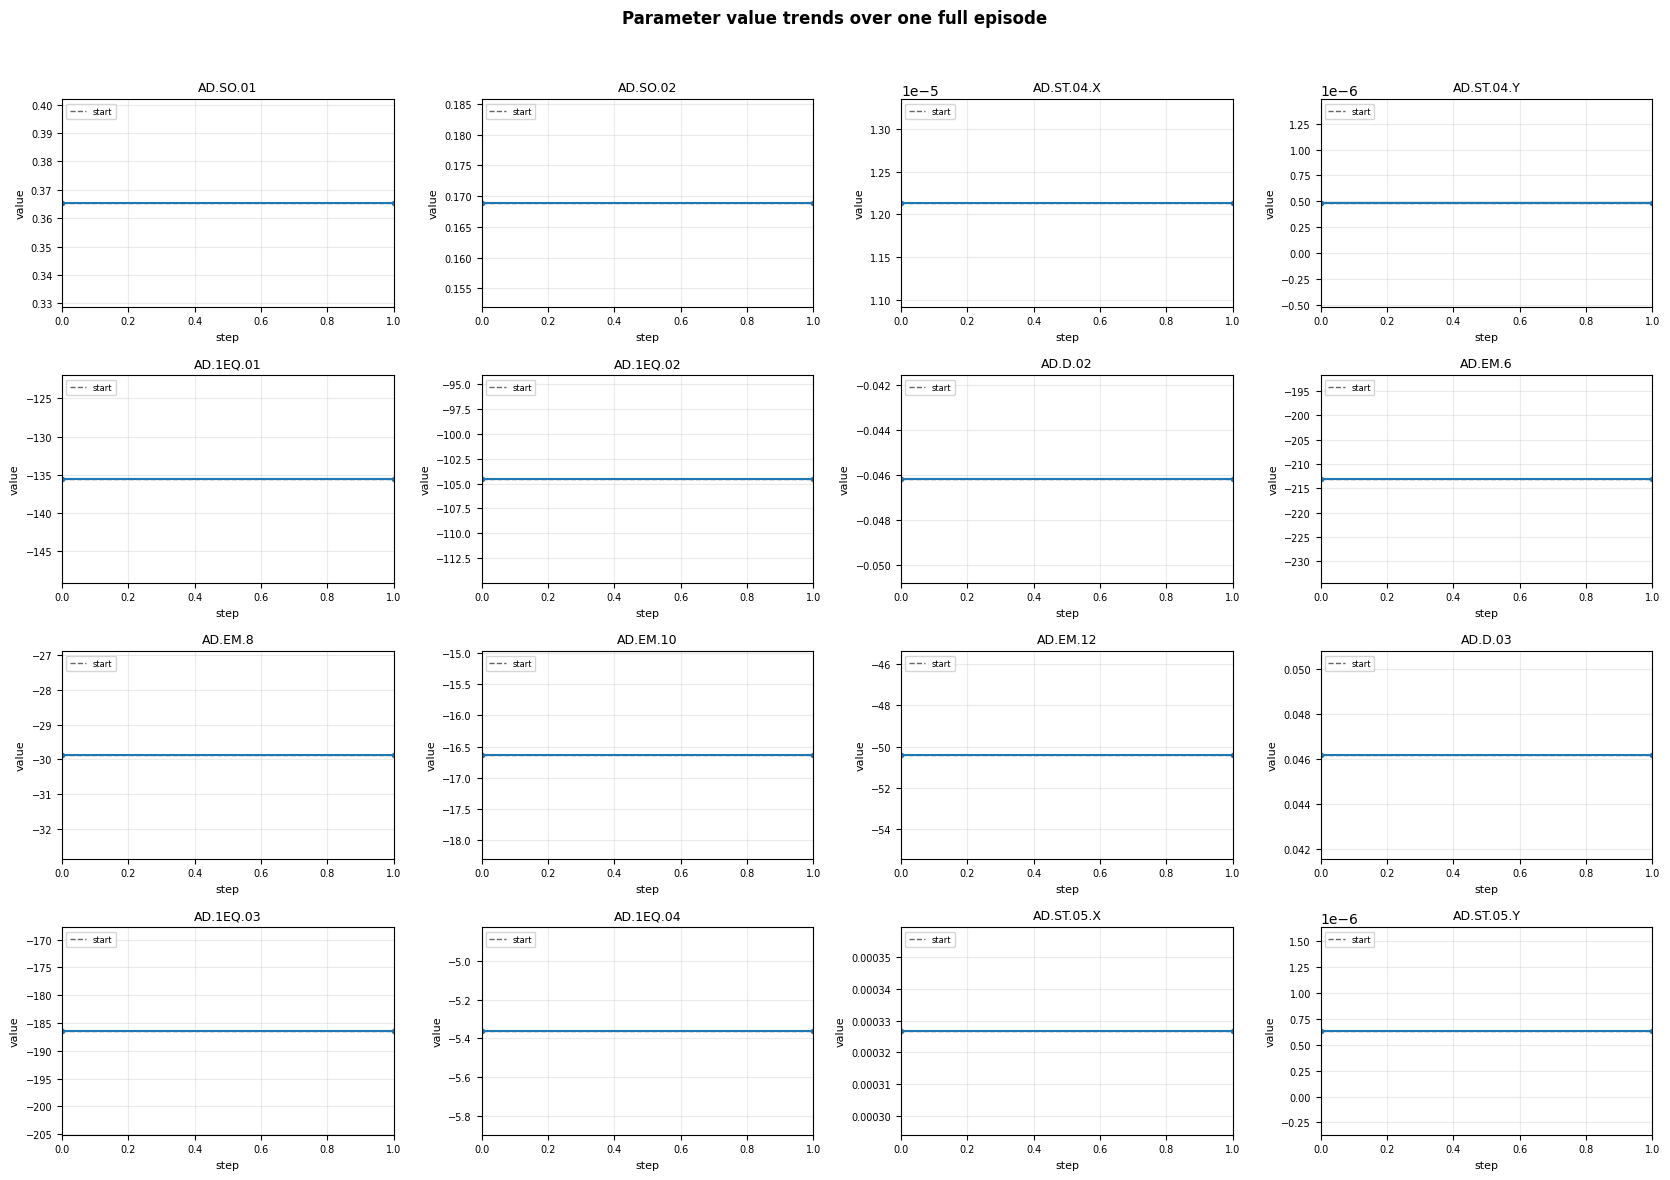

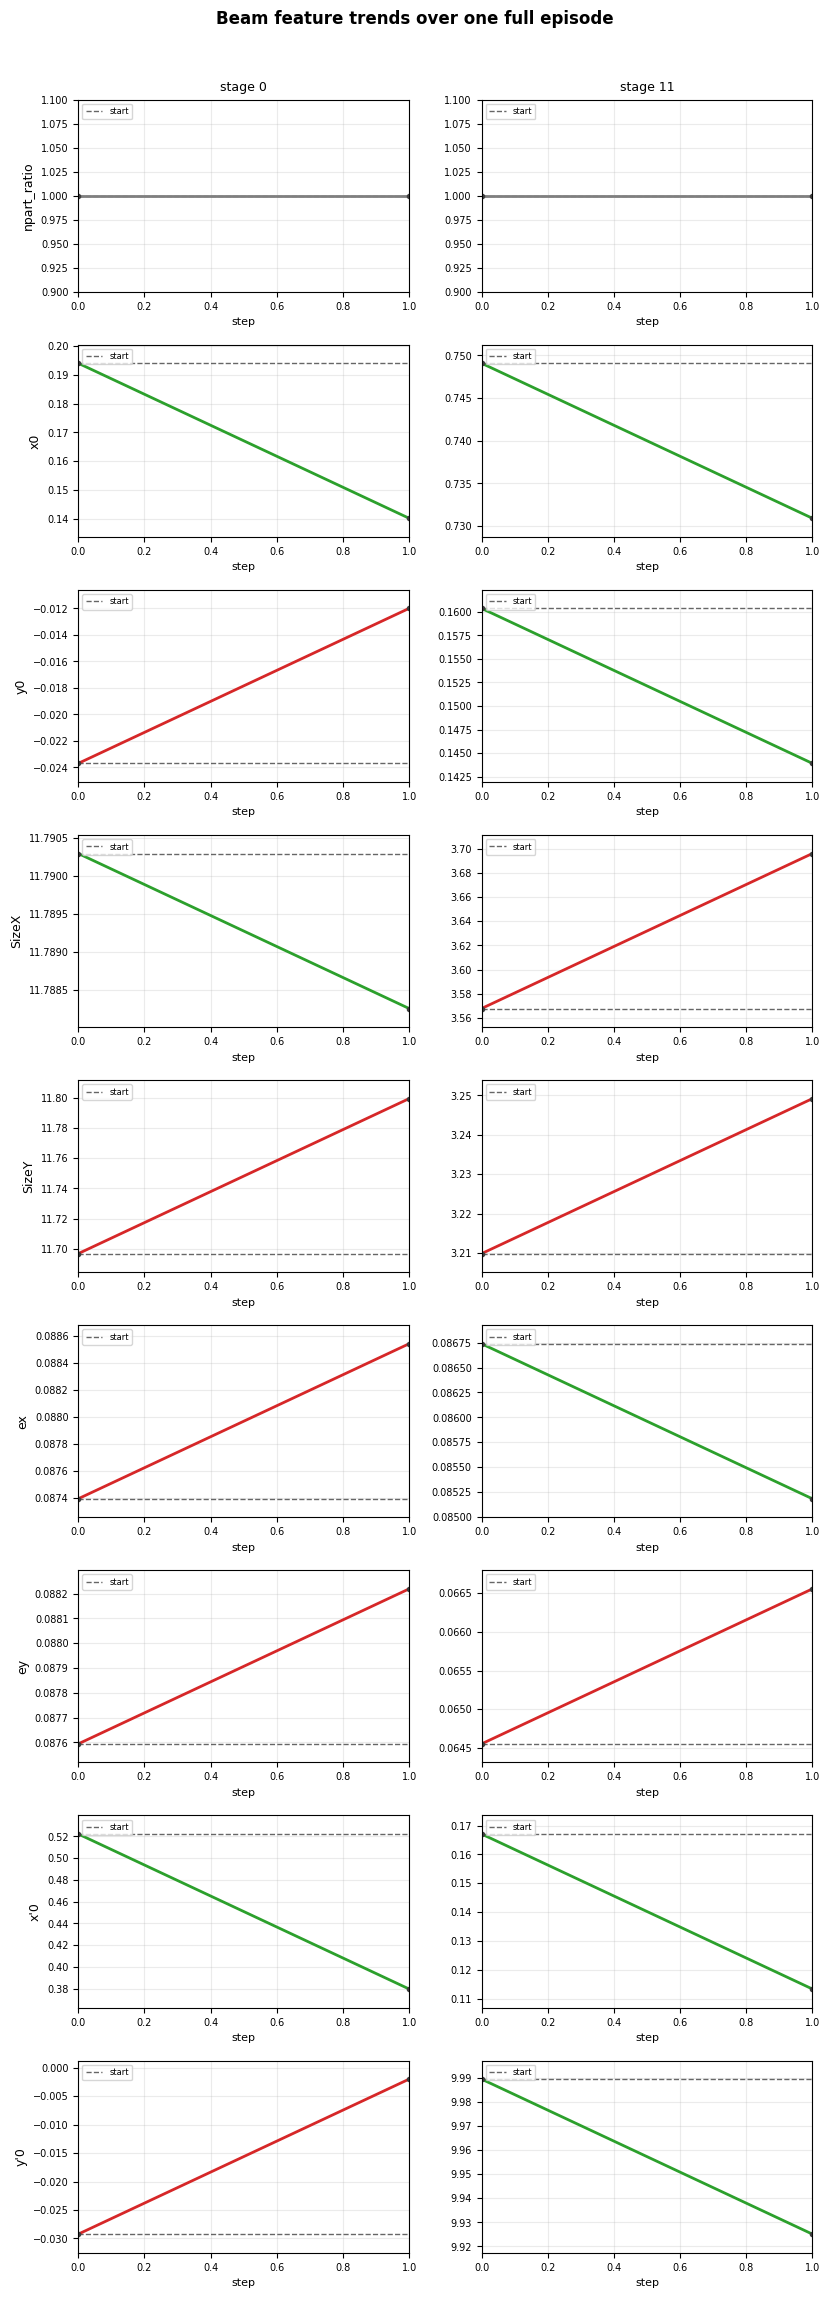

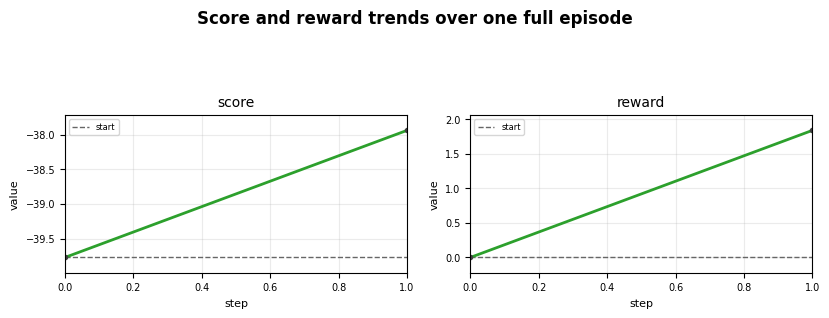

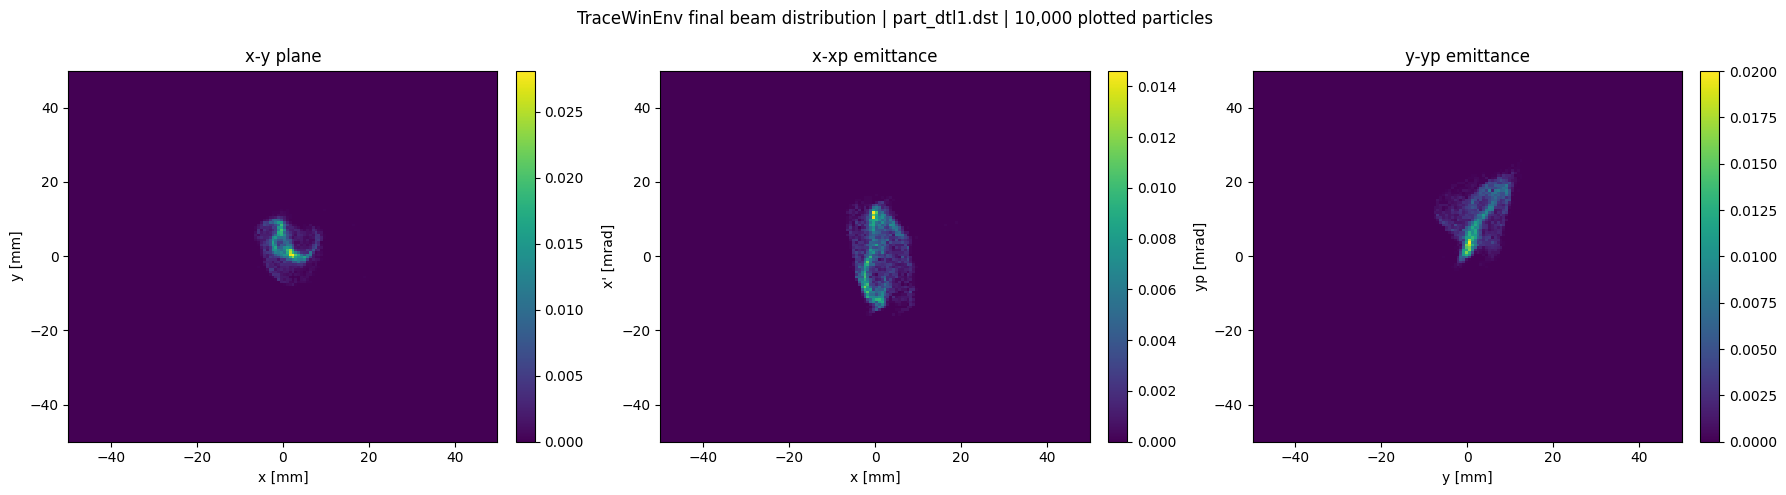

saved render files:
  params: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_params.png
  state: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_state.png
  score: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_score.png
  beam_distribution: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_beam_distribution.png


In [19]:
# Optional: render the episode trends and, if a .dst exists, the final beam distribution.
# The figures are saved as PNGs instead of printing the full Figure objects.
try:
    import matplotlib.pyplot as plt

    render_result = env.render(render_beam_distribution=True, max_particles=40000, bins=150)
    render_paths = {}

    for name, fig in render_result.items():
        if fig is None or not hasattr(fig, "savefig"):
            continue
        output_path = calc_dir / f"debug_render_{name}.png"
        fig.savefig(output_path, dpi=130)
        plt.close(fig)
        render_paths[name] = output_path

    if render_paths:
        print("saved render files:")
        for name, output_path in render_paths.items():
            print(f"  {name}: {output_path}")
    else:
        print("no render figures were produced")
except Exception:
    traceback.print_exc()
